# ASSIGNMENT 2: Hotel Harmony: Data Insights for Optimized Operations

# IMPORTING LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTING DATASET

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Step 1: Basic Dataset Inspection

In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## Step 2: Missing Values Analysis 

In [6]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [7]:
round((df.isnull().sum()/len(df))*100,2)

hotel                              0.00
is_canceled                        0.00
lead_time                          0.00
arrival_date_year                  0.00
arrival_date_month                 0.00
arrival_date_week_number           0.00
arrival_date_day_of_month          0.00
stays_in_weekend_nights            0.00
stays_in_week_nights               0.00
adults                             0.00
children                           0.00
babies                             0.00
meal                               0.00
country                            0.41
market_segment                     0.00
distribution_channel               0.00
is_repeated_guest                  0.00
previous_cancellations             0.00
previous_bookings_not_canceled     0.00
reserved_room_type                 0.00
assigned_room_type                 0.00
booking_changes                    0.00
deposit_type                       0.00
agent                             13.69
company                           94.31


### Before filling or dropping anything, let's investigate each column.

**Company Column**

In [8]:
df['company'].nunique()

352

In [9]:
df['company'].value_counts().head(10)

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
Name: count, dtype: int64

**Agent Column**

In [10]:
df['agent'].nunique()

333

In [11]:
df['agent'].value_counts().head(10)

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

**Country Column**

In [12]:
df['country'].nunique()

177

In [13]:
df['country'].value_counts().head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

**Children Column**

In [14]:
df[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


## Handling Missing Value

### Company Column

Drop company 

Reason:

- More than 94% missing.
- Imputation would be unreliable.
- Very little information available for analysis.

In [15]:
df.drop('company', axis=1, inplace=True)

### Agent Column

In hotel booking datasets, missing agent values generally indicate:

Booking was made directly without a travel agent.

- Replace NaN with 0

In [16]:
df['agent'] = df['agent'].fillna(0)

In [17]:
df['agent'] = df['agent'].astype(int) # Convert to int

### Country Column

Top country:

PRT (Portugal)

Do NOT fill with Portugal.

That would artificially increase Portuguese bookings.

Instead:

- Replace with "Unknown"

In [18]:
df['country'] = df['country'].fillna('Unknown')

### Children Column

In [19]:
df[df['children'].isnull()][[
    'adults',
    'children',
    'babies',
    'hotel',
    'is_canceled'
]]

,adults,children,babies,hotel,is_canceled
40600,2,NaN,0,City Hotel,1
40667,2,NaN,0,City Hotel,1
40679,3,NaN,0,City Hotel,1
41160,2,NaN,0,City Hotel,1


**Filling Missing Children Values with 0**

In [20]:
df['children'] = df['children'].fillna(0)

In [21]:
df['children'] = df['children'].astype(int) # Convert to int

**Verify Missing Valules**

In [22]:
df.isnull().sum().sort_values(ascending=False)

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## Step 3: Handling Duplicate Records

In [23]:
df[df.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,No Deposit,240,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,No Deposit,240,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [24]:
df.duplicated().sum()/len(df)*100

np.float64(26.803752408074377)

In [25]:
df = df.drop_duplicates()

In [26]:
print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Shape after removing duplicates: (87389, 31)
Remaining duplicates: 0


## Step 4: Data Type Validation

In [27]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

## Step 5: Missing Value Treatment

In [28]:
df['agent'].value_counts().head()

agent
9      28757
240    13027
0      12189
14      3349
7       3300
Name: count, dtype: int64

In [29]:
df['country'].value_counts().head()

country
PRT    27449
GBR    10432
FRA     8837
ESP     7252
DEU     5387
Name: count, dtype: int64

In [30]:
df[df['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


## Step 6: Check Invalid Guest Records

In [31]:
invalid_guests = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

print("Invalid Guest Records:", len(invalid_guests))
invalid_guests.head()

Invalid Guest Records: 166


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,1,No Deposit,0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,0,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,0,No Deposit,38,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,1,No Deposit,308,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,1,No Deposit,308,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


A hotel booking should have at least one guest.

These 166 records represent bookings with:

- No adults
- No children
- No babies

Therefore:

Total Guests = 0

This is logically invalid because nobody is staying in the hotel.

- Remove these records

In [32]:
df = df[~(
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
)]

### Verify

In [33]:
invalid_guests = df[
    (df['adults'] == 0) &
    (df['children'] == 0) &
    (df['babies'] == 0)
]

print(len(invalid_guests))

0


## Step 7: Create Total Guest Column

In [34]:
df['total_guests'] = (
    df['adults']
    + df['children']
    + df['babies']
)

In [35]:
df['total_guests'].describe()

count    87223.000000
mean         2.029167
std          0.790135
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         55.000000
Name: total_guests, dtype: float64

## Step 8: Check Stay Duration

In [36]:
df['total_stay'] = (
    df['stays_in_week_nights']
    + df['stays_in_weekend_nights']
)

In [37]:
df[df['total_stay']==0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,...,240,0,Transient,0.0,0,2,Check-Out,2015-07-06,2,0
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,...,250,0,Transient,0.0,0,0,Check-Out,2015-07-06,1,0
196,Resort Hotel,0,8,2015,July,28,7,0,0,2,...,0,0,Transient,0.0,0,1,Check-Out,2015-07-07,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,City Hotel,0,15,2017,July,27,6,0,0,1,...,14,0,Transient-Party,0.0,0,0,Check-Out,2017-07-06,1,0
117701,City Hotel,0,0,2017,August,32,8,0,0,2,...,262,0,Transient,0.0,0,0,Check-Out,2017-08-08,2,0
118029,City Hotel,0,0,2017,August,33,14,0,0,2,...,0,0,Transient,0.0,0,0,Check-Out,2017-08-14,2,0
118631,City Hotel,0,78,2017,August,34,23,0,0,1,...,98,0,Transient-Party,0.0,0,0,Check-Out,2017-08-23,1,0


## Step 9: Check ADR Values

**Summary Statistics**

In [38]:
df['adr'].describe()

count    87223.000000
mean       106.519872
std         54.890351
min         -6.380000
25%         72.250000
50%         98.200000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

**Check Negative ADR Values**

In [39]:
df[df['adr']<0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_stay
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,2,10


**Count Negative ADR Values**

In [40]:
print("Negative ADR Records:", len(df[df['adr'] < 0]))

Negative ADR Records: 1


**Check Top 10 Highest ADR Values**

In [41]:
df['adr'].sort_values(ascending=False).head(10)

48515     5400.00
111403     510.00
15083      508.00
103912     451.50
13142      450.00
13391      437.00
39155      426.25
39568      402.00
39118      397.38
13323      392.00
Name: adr, dtype: float64

**Visualize ADR Distribution**

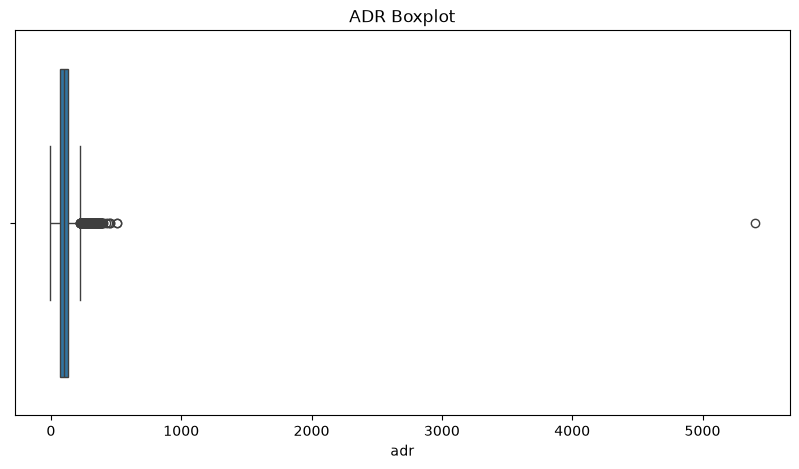

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['adr'])
plt.title('ADR Boxplot')
plt.show()

**Issue 1: Negative ADR**

Negative ADR Records: 1

ADR = -6.38

**Interpretation**

ADR cannot logically be negative.

**Possible reasons:**

- Data entry error
- Refund adjustment
- Accounting correction

Decision
- Remove this record

In [43]:
df = df[df['adr'] >= 0]

## Step 10: Check for Zero-Night Stay

In [44]:
df['total_stay'] = (
    df['stays_in_week_nights']
    + df['stays_in_weekend_nights']
)

print("Zero Stay Records:", len(df[df['total_stay'] == 0]))

df[df['total_stay'] == 0].head()

Zero Stay Records: 591


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,...,240,0,Transient,0.0,0,2,Check-Out,2015-07-06,2,0
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,...,250,0,Transient,0.0,0,0,Check-Out,2015-07-06,1,0
196,Resort Hotel,0,8,2015,July,28,7,0,0,2,...,0,0,Transient,0.0,0,1,Check-Out,2015-07-07,2,0


**Finding**

Zero Stay Records: 591

These records have:

- stays_in_week_nights = 0
- stays_in_weekend_nights = 0
- total_stay = 0

Before Removing Them

Let's investigate whether these are:

- Cancelled bookings
- Same-day bookings
- Data quality issues

In [45]:
df[df['total_stay'] == 0]['is_canceled'].value_counts()

is_canceled
0    568
1     23
Name: count, dtype: int64

In [46]:
df[df['total_stay'] == 0][
    ['hotel','is_canceled','reservation_status']
].head(10)

,hotel,is_canceled,reservation_status
0,Resort Hotel,0,Check-Out
1,Resort Hotel,0,Check-Out
167,Resort Hotel,0,Check-Out
168,Resort Hotel,0,Check-Out
196,Resort Hotel,0,Check-Out
197,Resort Hotel,0,Check-Out
459,Resort Hotel,0,Check-Out
568,Resort Hotel,0,Check-Out
569,Resort Hotel,0,Check-Out
618,Resort Hotel,0,Check-Out


**Decision**

✅ Keep the 591 records

Reason:

- Majority are valid completed bookings.
- Removing them would delete real booking activity.
- The dataset creators did not flag them as invalid records.

## Step 11: Check Outliers

In [47]:
numerical_cols = [
    'lead_time',
    'adr',
    'adults',
    'children',
    'babies',
    'booking_changes'
]

### Count Outliers Using IQR

In [48]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"{col}: {len(outliers)} outliers")

lead_time: 2394 outliers
adr: 2508 outliers
adults: 22728 outliers
children: 8364 outliers
babies: 914 outliers
booking_changes: 15804 outliers


### Visualization

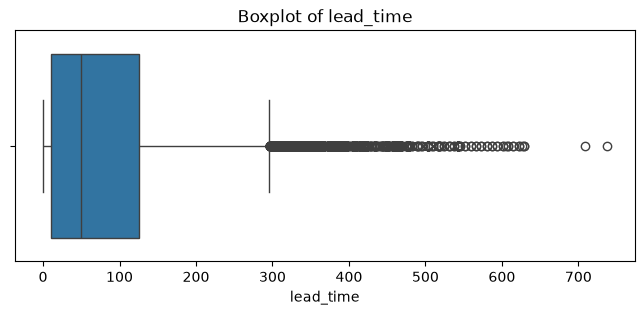

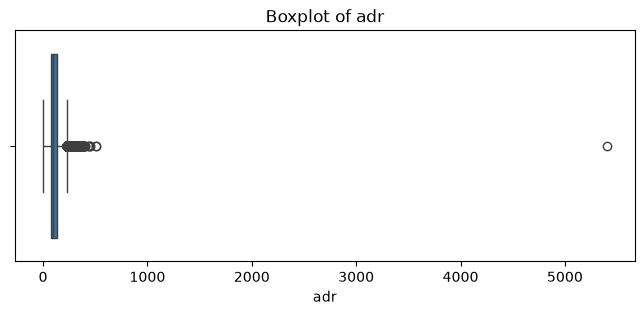

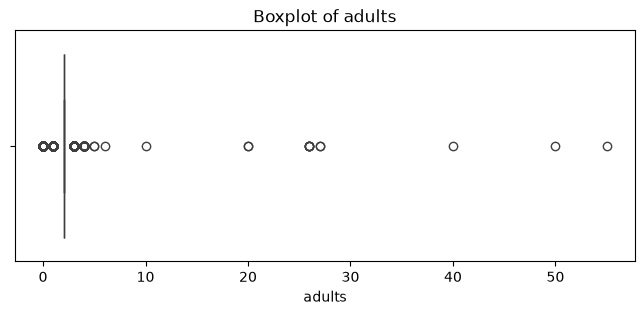

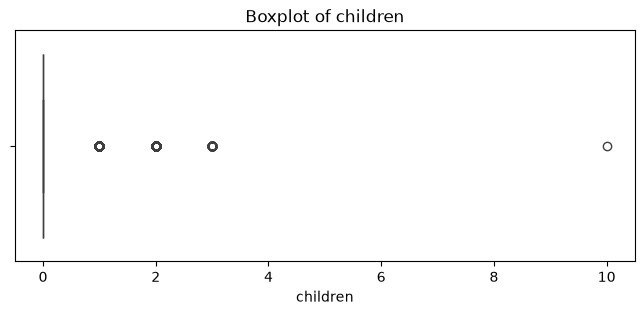

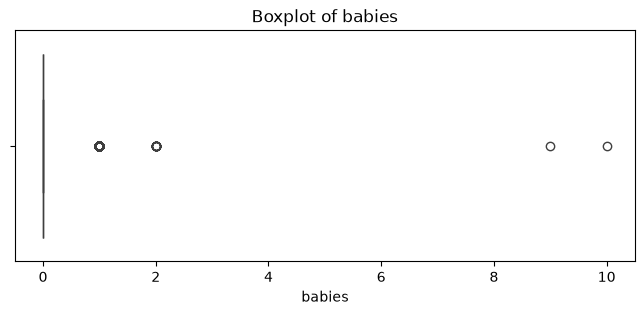

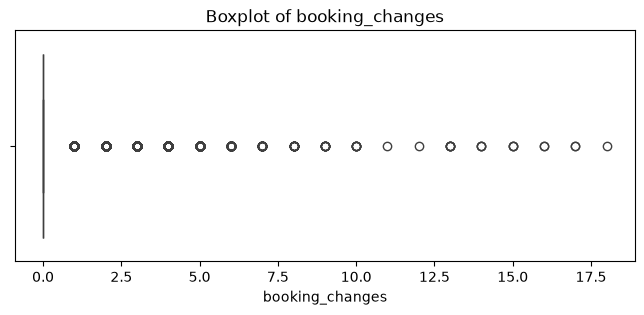

In [49]:
for col in numerical_cols:
    
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [50]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87222.0,79.975545,86.059240,0.0,11.00,49.0,125.0,737.0
adr,87222.0,106.521167,54.889335,0.0,72.25,98.2,134.1,5400.0
adults,87222.0,1.879411,0.621716,0.0,2.00,2.0,2.0,55.0
children,87222.0,0.138910,0.456284,0.0,0.00,0.0,0.0,10.0
babies,87222.0,0.010846,0.113709,0.0,0.00,0.0,0.0,10.0
booking_changes,87222.0,0.268499,0.710637,0.0,0.00,0.0,0.0,18.0


### Checking outliers of suspicious records

### Adults

In [51]:
df[df['adults'] > 10][
    ['hotel','adults','children','babies','is_canceled']
].head(20)

,hotel,adults,children,babies,is_canceled
1539,Resort Hotel,40,0,0,1
1587,Resort Hotel,26,0,0,1
1643,Resort Hotel,50,0,0,1
1752,Resort Hotel,26,0,0,1
1884,Resort Hotel,26,0,0,1
1917,Resort Hotel,27,0,0,1
1962,Resort Hotel,27,0,0,1
2003,Resort Hotel,26,0,0,1
2164,Resort Hotel,26,0,0,1
2173,Resort Hotel,55,0,0,1


### Childrens

In [52]:
df[df['children'] > 5][
    ['hotel','adults','children','babies','is_canceled']
].head(20)

,hotel,adults,children,babies,is_canceled
328,Resort Hotel,2,10,0,1


### Babies

In [53]:
df[df['babies'] > 3][
    ['hotel','adults','children','babies','is_canceled']
].head(20)

,hotel,adults,children,babies,is_canceled
46619,City Hotel,2,0,10,0
78656,City Hotel,1,0,9,0


### ADR

In [54]:
df[df['adr'] > 1000][
    ['hotel','adr','adults','children','total_stay','is_canceled']
]

,hotel,adr,adults,children,total_stay,is_canceled
48515,City Hotel,5400.0,2,0,1,1


### Before Handling Outliers

**Final Validation**

**Adults Analysis**

In [55]:
df['adults'].value_counts().sort_index().tail(20)

adults
0       219
1     16498
2     64494
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

**Observation**

Values:

20, 26, 27, 40, 50, 55

occur only 13 times in the entire dataset.

These are extremely rare and most likely:

- Data entry issues
- Bulk/group reservation anomalies

**Decision**

Remove records where: adults >=10

In [56]:
df = df[df['adults'] <= 10]

**Babies Analysis**

In [57]:
df['babies'].value_counts().sort_index()

babies
0     86296
1       897
2        15
9         1
10        1
Name: count, dtype: int64

**Observation**

These two records:

- 9 babies
- 10 babies

are highly unrealistic.

**Decision**

Remove records where: babies <= 3

In [58]:
df = df[df['babies'] <= 3]

**ADR Analysis**

We previously found:

ADR = 5400

Only one extreme record.

Remove: ADR < 1000

In [59]:
df = df[df['adr'] < 1000]

## Step 12: Create Proper Date Column

In [60]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str)
    + '-' +
    df['arrival_date_month']
    + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

## Step 13: Country Mapping

In [61]:
country_mapping = {
    'PRT': 'Portugal',
    'GBR': 'United Kingdom',
    'FRA': 'France',
    'ESP': 'Spain',
    'DEU': 'Germany',
    'ITA': 'Italy',
    'IRL': 'Ireland',
    'BEL': 'Belgium',
    'BRA': 'Brazil',
    'NLD': 'Netherlands'
}

df['country'] = df['country'].replace(country_mapping)

In [62]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_stay,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,2015-07-01
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,2015-07-01
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,2015-07-01


In [ ]:
df_cleaned = df.copy()

In [64]:
df_cleaned.to_csv('hotel_bookings_cleaned.csv', index=False)

~95% of the data cleaning is complete.

Completed Cleaning Tasks

✅ Duplicates Removed

✅ Missing Values Handled

✅ Invalid Records Removed

✅ Date Features Created

✅ Guest Features Created

✅ Extreme Outliers Removed

✅ Country Mapping 

✅ Dataset Ready for Exploratory Data Analysis (EDA)

# BASIC LEVEL QUESTIONS

## 1. What is the average lead time for bookings?

In [65]:
average_lead_time = df_cleaned['lead_time'].mean()

print("Average Lead Time:", round(average_lead_time, 2), "days")

Average Lead Time: 79.94 days


### Visualization

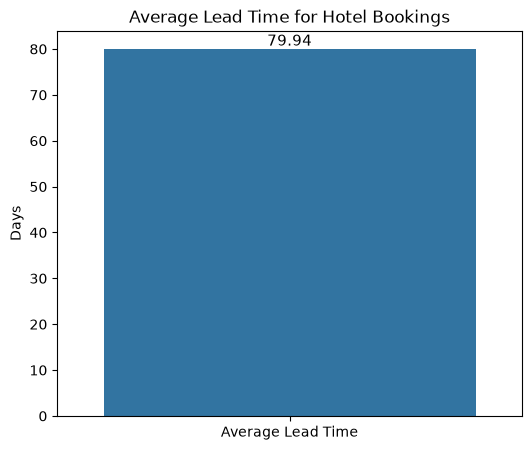

In [66]:
avg_lead_time = df_cleaned['lead_time'].mean()

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=['Average Lead Time'],
    y=[avg_lead_time]
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Average Lead Time for Hotel Bookings')
plt.ylabel('Days')
plt.xlabel('')

plt.show()

**Business Insight**

Knowing the average lead time helps hotel management forecast future occupancy levels and design promotional campaigns during periods with lower booking activity.

**Conclusion**

The average booking lead time is approximately 80 days, showing that advance reservations are common among hotel guests. This information can support better demand forecasting and revenue management strategies.

## 2. What is the distribution of bookings by hotel type?

In [67]:
hotel_bookings = df_cleaned['hotel'].value_counts()

print(hotel_bookings)

hotel
City Hotel      53269
Resort Hotel    33938
Name: count, dtype: int64


### Visualization

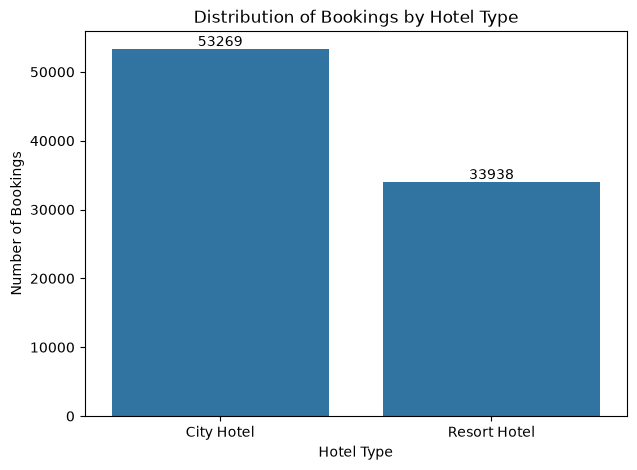

In [68]:
hotel_bookings = df_cleaned['hotel'].value_counts()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=hotel_bookings.index,
    y=hotel_bookings.values
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribution of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.show()

**Business Insight**

The higher demand for City Hotels suggests that most guests prefer urban locations, likely due to business travel, convenience, and accessibility. Management can focus more marketing efforts, staffing, and revenue optimization strategies on City Hotels while developing targeted promotions to increase Resort Hotel bookings.

**Conclusion**

City Hotels dominate the booking distribution with over 61% of total reservations, making them the primary revenue-driving hotel type for Elite Hotels International. Understanding this preference can help management allocate resources more effectively and design hotel-specific growth strategies.

## 3. How many bookings were canceled?

In [69]:
cancelled_bookings = df_cleaned['is_canceled'].sum()

print("Total Cancelled Bookings:", cancelled_bookings)

Total Cancelled Bookings: 23996


### Visualization

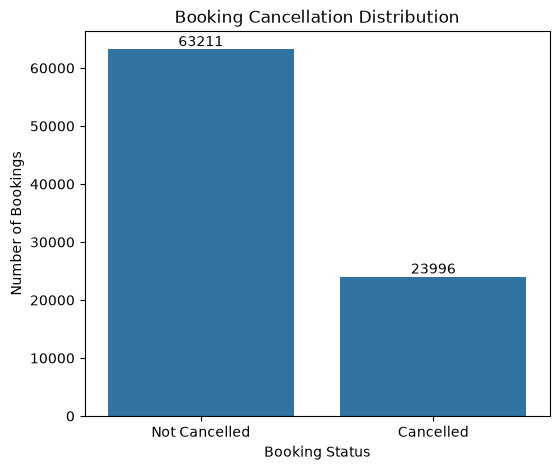

In [70]:
cancellation_data = df_cleaned['is_canceled'].value_counts()

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=['Not Cancelled', 'Cancelled'],
    y=[cancellation_data[0], cancellation_data[1]]
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Booking Cancellation Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.show()

**Business Insight**

A cancellation rate of over 27% can significantly affect occupancy planning, revenue forecasting, and resource allocation. The hotel should investigate factors such as booking lead time, deposit policies, and market segments that contribute most to cancellations to reduce revenue loss.

**Conclusion**

23,996 bookings were cancelled, resulting in a cancellation rate of 27.52%. This highlights the importance of understanding cancellation behavior and implementing strategies to improve booking retention and operational efficiency.

## 4. What is the most common arrival month for bookings?

In [71]:
month_bookings = df_cleaned['arrival_date_month'].value_counts()

print(month_bookings)

print("\nMost Common Arrival Month:")
print(month_bookings.idxmax())

arrival_date_month
August       11242
July         10042
May           8343
April         7900
June          7756
March         7487
October       6916
September     6673
February      6082
December      5111
November      4971
January       4684
Name: count, dtype: int64

Most Common Arrival Month:
August


### Visualization

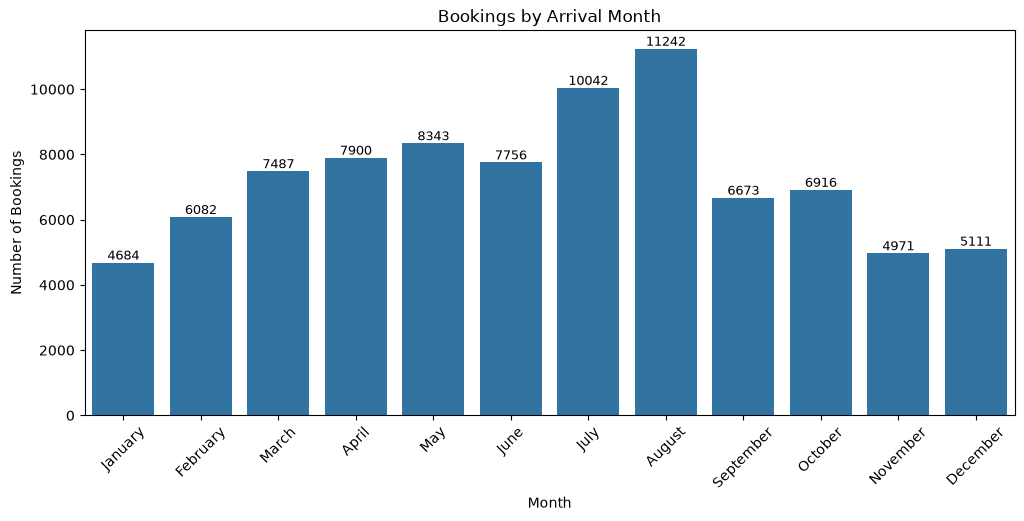

In [72]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

month_data = (
    df_cleaned['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=month_data.index,
    y=month_data.values
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Bookings by Arrival Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)

plt.show()

**Business Insight**

Since August attracts the highest number of guests, hotel management should increase staffing levels, optimize room pricing, and ensure adequate inventory and service availability during this peak season. Dynamic pricing strategies can also be used to maximize revenue.

**Conclusion**

August is the most common arrival month for bookings, accounting for 11,242 reservations. The strong concentration of bookings in July and August highlights a clear seasonal demand pattern that can be leveraged for revenue optimization and operational planning.

## 5. What is the average number of special requests per booking?

In [73]:
avg_special_requests = df_cleaned['total_of_special_requests'].mean()

print(f"Average Special Requests per Booking: {avg_special_requests:.2f}")

Average Special Requests per Booking: 0.70


### Visualization

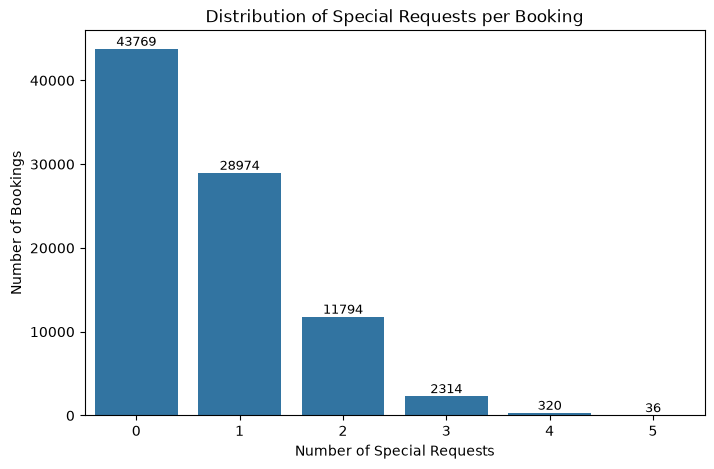

In [74]:
special_request_counts = (
    df_cleaned['total_of_special_requests']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=special_request_counts.index,
    y=special_request_counts.values
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Distribution of Special Requests per Booking')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')

plt.show()

**Business Insight**

Since most guests either make no requests or only one request, the hotel can efficiently manage standard operations while maintaining flexibility to accommodate occasional special needs. Tracking these requests can help improve personalization and guest satisfaction.

**Conclusion**

The average number of special requests per booking is 0.70, suggesting that special service requirements are generally low among hotel guests. However, effectively handling these requests can enhance the guest experience and contribute to higher customer satisfaction.

## 6. Which country has the highest number of bookings?

In [75]:
country_bookings = df_cleaned['country'].value_counts()

print(country_bookings.head(10))

print("\nCountry with Highest Bookings:")
print(country_bookings.idxmax())

print("Total Bookings:")
print(country_bookings.max())

country
Portugal          27337
United Kingdom    10421
France             8823
Spain              7244
Germany            5385
Italy              3061
Ireland            3015
Belgium            2081
Brazil             1993
Netherlands        1910
Name: count, dtype: int64

Country with Highest Bookings:
Portugal
Total Bookings:
27337


### Visualization

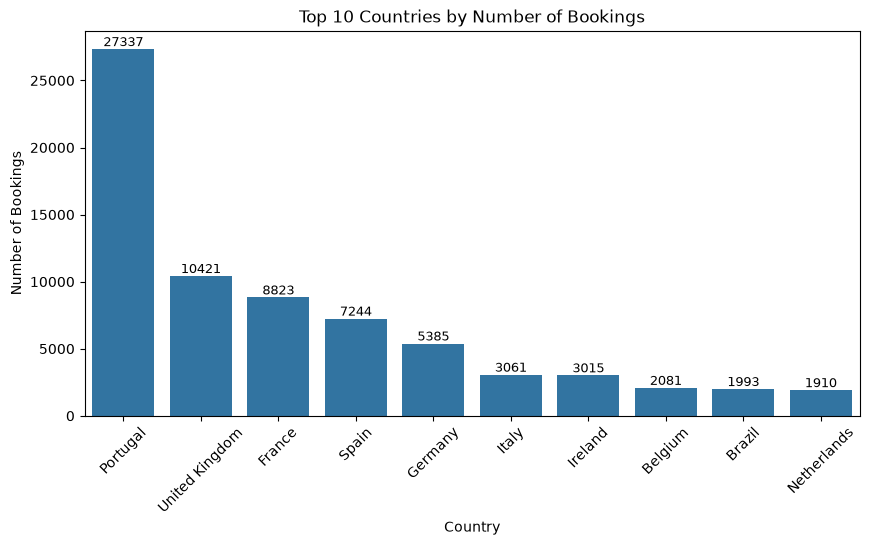

In [76]:
top_10_countries = df_cleaned['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top_10_countries.index,
    y=top_10_countries.values
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)

plt.show()

### Calculate Percentage Contribution

In [77]:
top_country = country_bookings.idxmax()
top_country_count = country_bookings.max()

percentage = (top_country_count / len(df_cleaned)) * 100

print(f"Country: {top_country}")
print(f"Bookings: {top_country_count}")
print(f"Percentage of Total Bookings: {percentage:.2f}%")

Country: Portugal
Bookings: 27337
Percentage of Total Bookings: 31.35%


**Business Insight**

Portugal represents the hotel's strongest customer base. Management can strengthen customer loyalty programs, targeted promotions, and localized marketing campaigns in Portugal while also exploring growth opportunities in other high-performing markets such as the UK, France, and Spain.

**Conclusion**

Portugal is the leading source of hotel bookings with 27,337 reservations (31.35% of total bookings). This highlights Portugal as the most important customer market for Elite Hotels International and a key region for future marketing and revenue growth initiatives.

## 7. What is the average daily rate (ADR) for each hotel type?

In [78]:
hotel_adr = (
    df_cleaned
    .groupby('hotel')['adr']
    .mean()
    .sort_values(ascending=False)
)

print(hotel_adr.round(2))

hotel
City Hotel      111.17
Resort Hotel     99.10
Name: adr, dtype: float64


### Visualization

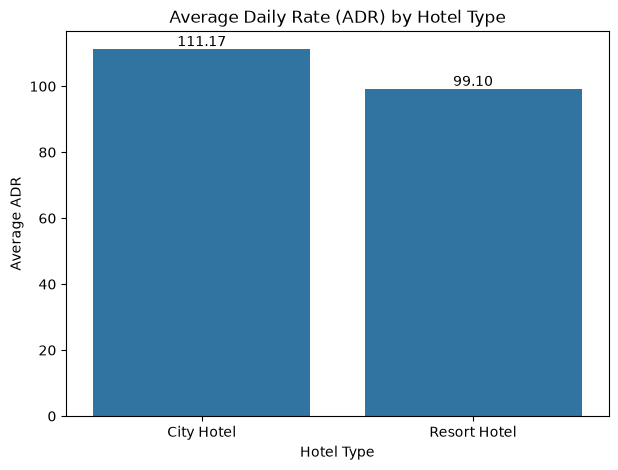

In [79]:
hotel_adr = (
    df_cleaned
    .groupby('hotel')['adr']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=hotel_adr,
    x='hotel',
    y='adr'
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Average Daily Rate (ADR) by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')

plt.show()

**Business Insight**

The hotel chain earns more revenue per booked room in City Hotels. Management should analyze the factors driving higher pricing in City Hotels and explore whether similar pricing strategies, service offerings, or promotional packages can be applied to Resort Hotels to improve revenue.

**Conclusion**

City Hotels outperform Resort Hotels in terms of average room pricing, with an ADR that is approximately 12% higher. This suggests stronger revenue-generating potential for City Hotels and highlights the importance of optimizing pricing strategies across different hotel types.

## 8. What percentage of guests required car parking spaces?

In [80]:
parking_required = (df_cleaned['required_car_parking_spaces'] > 0).sum()

parking_percentage = (parking_required / len(df_cleaned)) * 100

print(f"Bookings Requiring Parking: {parking_required}")
print(f"Percentage of Total Bookings: {parking_percentage:.2f}%")

Bookings Requiring Parking: 7306
Percentage of Total Bookings: 8.38%


### Visualization

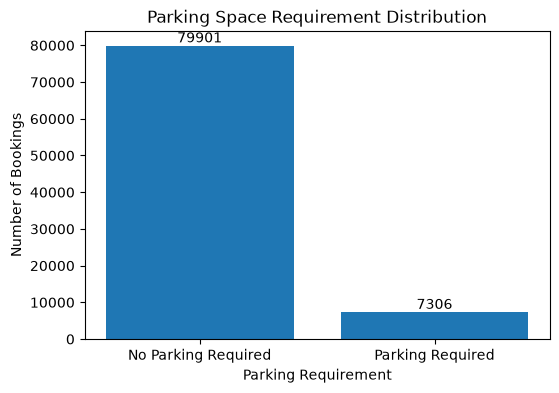

In [81]:
parking_counts = pd.Series({
    'No Parking Required':
        (df_cleaned['required_car_parking_spaces'] == 0).sum(),
    'Parking Required':
        (df_cleaned['required_car_parking_spaces'] > 0).sum()
})

plt.figure(figsize=(6,4))
bars = plt.bar(parking_counts.index, parking_counts.values)

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom'
    )

plt.title('Parking Space Requirement Distribution')
plt.xlabel('Parking Requirement')
plt.ylabel('Number of Bookings')
plt.show()

**Business Insight**

Since fewer than 1 in 10 bookings require parking, parking capacity is currently sufficient for most guests. The hotel can:

- Optimize unused parking areas for other operational purposes.
- Offer premium parking services or reserved parking packages.
- Focus parking-related investments only in locations where demand is higher.

**Conclusion**

Parking demand is limited, with only 7,306 bookings (8.38%) requiring parking spaces. This suggests that parking facilities are not a primary factor for most guests when booking hotels, and management can allocate resources accordingly while ensuring adequate parking availability for the small segment that requires it.

## 9. What is the average stay duration in week nights and weekend nights?

In [82]:
avg_week_nights = df_cleaned['stays_in_week_nights'].mean()
avg_weekend_nights = df_cleaned['stays_in_weekend_nights'].mean()

print(f"Average Week Nights Stay: {avg_week_nights:.2f}")
print(f"Average Weekend Nights Stay: {avg_weekend_nights:.2f}")

Average Week Nights Stay: 2.62
Average Weekend Nights Stay: 1.00


### Visualization

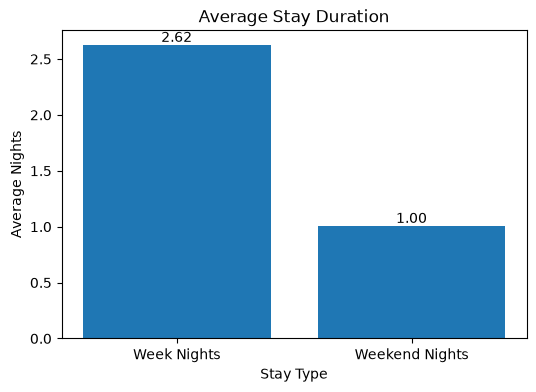

In [83]:
stay_avg = pd.Series({
    'Week Nights': df_cleaned['stays_in_week_nights'].mean(),
    'Weekend Nights': df_cleaned['stays_in_weekend_nights'].mean()
})

plt.figure(figsize=(6,4))
bars = plt.bar(stay_avg.index, stay_avg.values)

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Average Stay Duration')
plt.xlabel('Stay Type')
plt.ylabel('Average Nights')
plt.show()

**Business Insight**

Since guests spend more nights during weekdays than weekends:

- Hotels should focus on maximizing weekday occupancy through corporate partnerships and business travel packages.
- Weekend promotions can be introduced to encourage guests to extend their stay.
- Revenue management strategies can target higher weekday demand while boosting weekend occupancy through discounts and bundled offers.

**Conclusion**

The average guest stay consists of approximately 2.62 nights, with 72% of nights occurring on weekdays and 28% on weekends. This indicates a stronger demand for weekday accommodations and highlights opportunities to increase weekend bookings.

## 10. How many bookings were made through travel agents?

In [84]:
agent_bookings = (df_cleaned['agent'] != 0).sum()

agent_percentage = (
    agent_bookings / len(df_cleaned)
) * 100

print(f"Bookings Through Travel Agents: {agent_bookings}")
print(f"Percentage of Total Bookings: {agent_percentage:.2f}%")

Bookings Through Travel Agents: 75077
Percentage of Total Bookings: 86.09%


In [85]:
direct_bookings = (df_cleaned['agent'] == 0).sum()

print(f"Direct Bookings: {direct_bookings}")

Direct Bookings: 12130


### Visualization

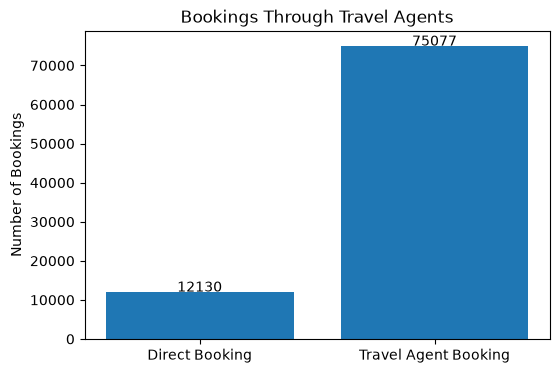

In [86]:
booking_type = pd.Series({
    'Direct Booking':
        (df_cleaned['agent'] == 0).sum(),
    'Travel Agent Booking':
        (df_cleaned['agent'] != 0).sum()
})

plt.figure(figsize=(6,4))
bars = plt.bar(
    booking_type.index,
    booking_type.values
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center'
    )

plt.title('Bookings Through Travel Agents')
plt.ylabel('Number of Bookings')
plt.show()

**Business Insight**

Travel agents are the primary booking channel for Elite Hotels International. This indicates strong dependence on intermediaries for customer acquisition. While travel agents help generate high booking volumes, they may also involve commission costs that impact profitability.

The hotel should:

- Maintain strong relationships with top-performing travel agents.
- Monitor agent performance regularly.
- Gradually increase direct booking channels through loyalty programs, website promotions, and exclusive offers to reduce commission expenses.

**Conclusion**

Travel agents play a critical role in the hotel's booking ecosystem, contributing more than 86% of all reservations. The business currently relies heavily on agent networks for occupancy and revenue generation, making agent relationship management a key strategic priority.

# MID LEVEL QUESTIONS

## 1. What is the cancellation rate for each hotel type?

In [87]:
cancellation_rate = (
    df_cleaned.groupby('hotel')['is_canceled']
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(cancellation_rate.round(2))

hotel
City Hotel      30.10
Resort Hotel    23.46
Name: is_canceled, dtype: float64


### Visualization

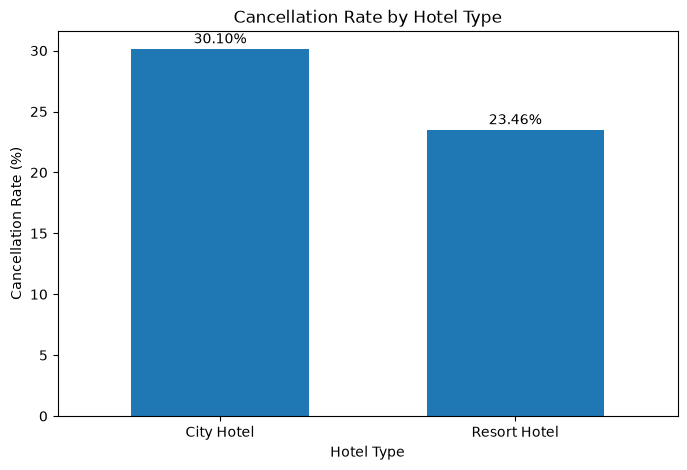

In [88]:
plt.figure(figsize=(8,5))

ax = cancellation_rate.plot(
    kind='bar',
    width=0.6
)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

# Add values on bars
for i, value in enumerate(cancellation_rate):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center')

plt.show()

**Business Insight**

- City Hotels have a higher cancellation rate (30.10%) compared to Resort Hotels (23.46%).
- Nearly 3 out of every 10 City Hotel bookings are cancelled.
- Resort Hotel guests appear to be more committed to their reservations, likely because leisure trips are planned further in advance and involve higher travel commitment.

**Conclusion**

City Hotels face a significantly greater cancellation risk than Resort Hotels.
Revenue forecasting and room inventory management are more challenging for City Hotels due to frequent cancellations.

The hotel management team should consider:
- Advance deposits for high-risk bookings.
- Flexible rebooking options instead of cancellations.
- Targeted reminder campaigns before arrival dates.
- Dynamic overbooking strategies based on historical cancellation patterns.

## 2. What is the average ADR per market segment?

In [89]:
segment_adr = (
    df_cleaned.groupby('market_segment')['adr']
    .mean()
    .sort_values(ascending=False)
)

print(segment_adr.round(2))

market_segment
Online TA        118.29
Direct           116.85
Aviation         100.61
Offline TA/TO     81.59
Groups            75.18
Corporate         68.37
Undefined         15.00
Complementary      3.09
Name: adr, dtype: float64


### Visualization

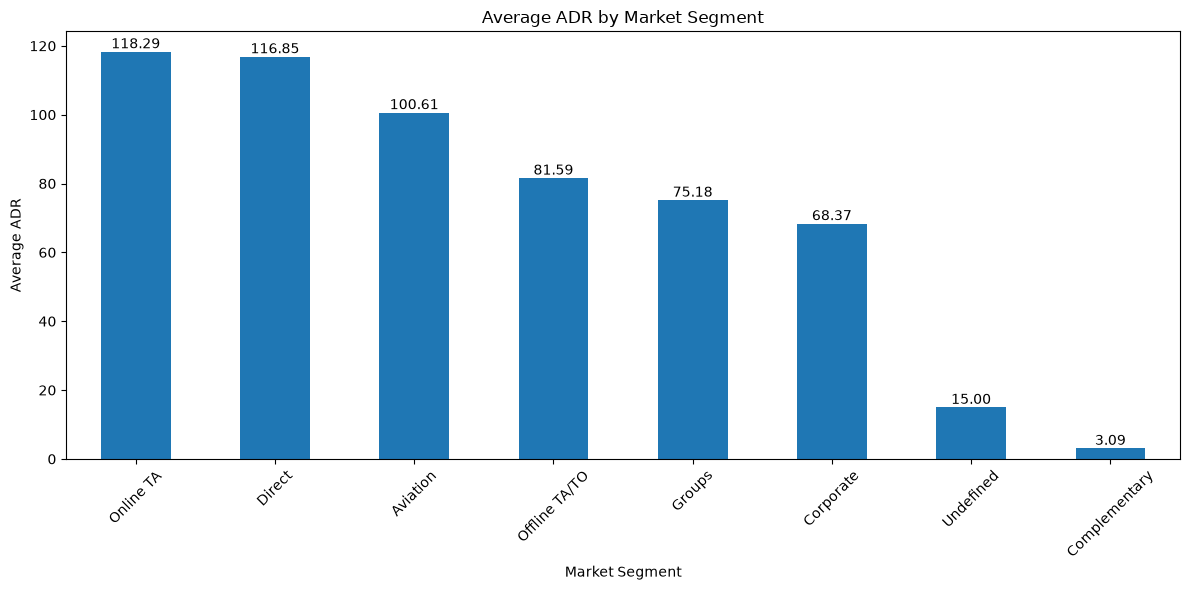

In [90]:
plt.figure(figsize=(12,6))

ax = segment_adr.plot(
    kind='bar'
)

plt.title('Average ADR by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Average ADR')
plt.xticks(rotation=45)

# Add values on bars
for i, value in enumerate(segment_adr):
    plt.text(i, value + 1, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

**Business Insight**

- Online TA bookings generate the highest average ADR (118.29), closely followed by Direct bookings (116.85).
- Aviation customers also contribute strong revenue with an ADR above 100.
- Corporate and Group segments have lower ADRs, likely due to negotiated rates and bulk booking discounts.
- Complementary bookings have an ADR close to zero because rooms are provided free of charge or as part of promotions.

**Conclusion**

- The hotel's highest revenue-generating segments are Online TA, Direct, and Aviation.
- Direct bookings are especially valuable because they provide nearly the same ADR as Online TA while typically avoiding third-party commission costs.
- Corporate and Group segments help maintain occupancy but generate lower revenue per room.
- The hotel should continue promoting Direct Bookings and optimize pricing strategies for Online Travel Agencies to maximize revenue.

## 3. What is the relationship between lead time and cancellation rate?

### Correlation between Lead time and cancellation

In [91]:
correlation = df_cleaned['lead_time'].corr(df_cleaned['is_canceled'])

print(f"Correlation between Lead Time and Cancellation: {correlation:.3f}")

Correlation between Lead Time and Cancellation: 0.184


### Visualization

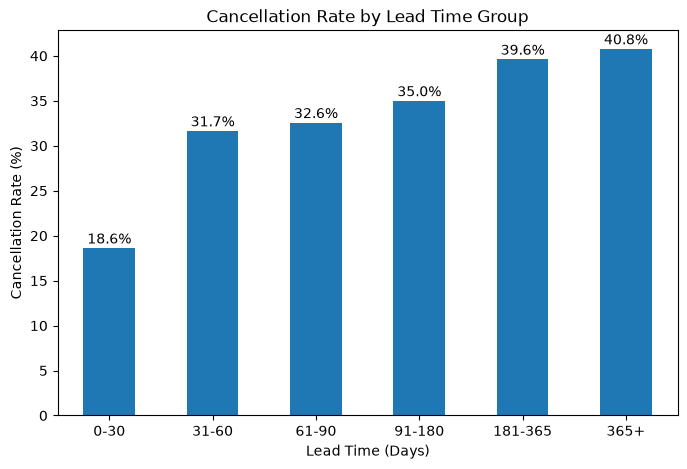

In [94]:
# Create lead time bins
df_cleaned['lead_time_group'] = pd.cut(
    df_cleaned['lead_time'],
    bins=[0, 30, 60, 90, 180, 365, 800],
    labels=['0-30', '31-60', '61-90', '91-180', '181-365', '365+']
)

# Calculate cancellation rate
cancel_rate = (
    df_cleaned.groupby('lead_time_group')['is_canceled']
    .mean() * 100
)

plt.figure(figsize=(8,5))

ax = cancel_rate.plot(kind='bar')

plt.title('Cancellation Rate by Lead Time Group')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)

# Add values on bars
for i, value in enumerate(cancel_rate):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

plt.show()

### Scatter Plot

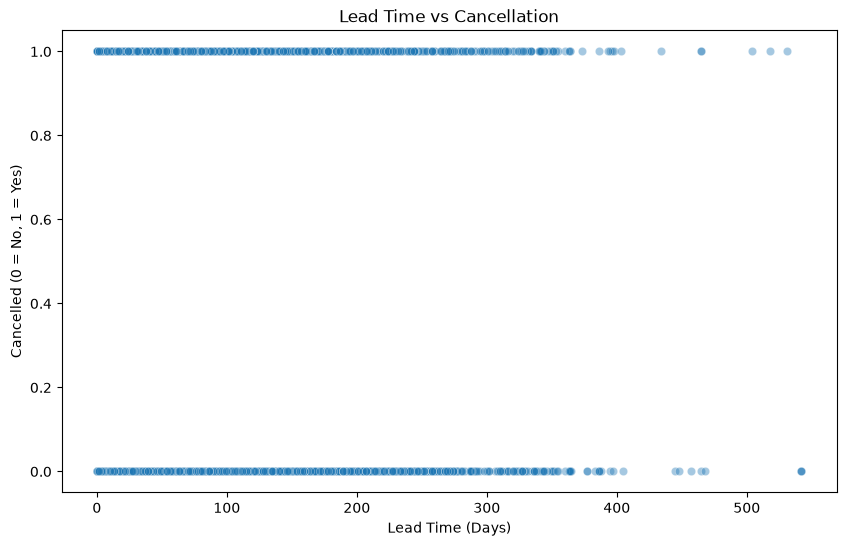

In [95]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_cleaned.sample(5000, random_state=42),
    x='lead_time',
    y='is_canceled',
    alpha=0.4
)

plt.title('Lead Time vs Cancellation')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancelled (0 = No, 1 = Yes)')

plt.show()

**Business Insight**

- Cancellation rates consistently increase as lead time increases.
- Guests booking within 30 days have the lowest cancellation rate (18.6%).
- Guests booking more than 365 days in advance have the highest cancellation rate (40.8%).
- The cancellation rate more than doubles from short-term bookings to very long-term bookings.
- Customers who book far in advance have more opportunities to change travel plans, compare prices, or cancel reservations.

**Conclusion**

- There is a positive relationship between lead time and cancellation likelihood.
- Although the correlation (0.184) is not very strong, the lead-time group analysis clearly shows that longer lead times are associated with higher cancellation rates.
- Long lead-time reservations represent a higher business risk and should be monitored carefully.

## 4. Which distribution channel has the highest number of bookings?

### Count bookings by distribution channel

In [96]:
channel_bookings = (
    df_cleaned['distribution_channel']
    .value_counts()
)

print(channel_bookings)

distribution_channel
TA/TO        69018
Direct       12946
Corporate     5057
GDS            181
Undefined        5
Name: count, dtype: int64


### Visualization

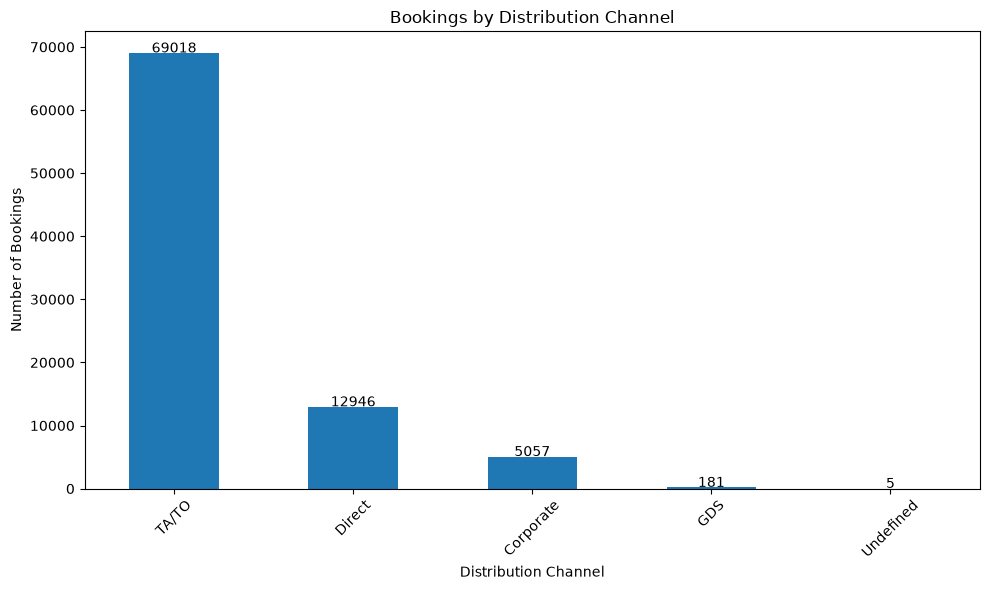

In [97]:
plt.figure(figsize=(10,6))

ax = channel_bookings.plot(
    kind='bar'
)

plt.title('Bookings by Distribution Channel')
plt.xlabel('Distribution Channel')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)

# Add values on bars
for i, value in enumerate(channel_bookings):
    plt.text(i, value + 100, str(value), ha='center')

plt.tight_layout()
plt.show()

### Highest Channel

In [98]:
top_channel = channel_bookings.idxmax()
top_bookings = channel_bookings.max()

percentage = (top_bookings / len(df_cleaned)) * 100

print(f"Top Distribution Channel: {top_channel}")
print(f"Bookings: {top_bookings}")
print(f"Percentage of Total Bookings: {percentage:.2f}%")

Top Distribution Channel: TA/TO
Bookings: 69018
Percentage of Total Bookings: 79.14%


**Business Insight**

- Travel Agents/Tour Operators (TA/TO) are the dominant booking source, contributing 79.14% of total bookings.
- The hotel's revenue and occupancy are highly dependent on third-party intermediaries.
- Direct bookings account for only 14.84%, indicating an opportunity to strengthen the hotel's own website, loyalty programs, and marketing campaigns.
- The Corporate segment contributes 5.80%, suggesting potential for growth through business partnerships and corporate contracts.
- Reliance on a single distribution channel can increase business risk if agent commissions rise or partnerships change.

**Conclusion**

The analysis shows that TA/TO is the leading distribution channel, generating 69,018 bookings (79.14%) of all reservations. This highlights the critical role of travel agents and tour operators in driving hotel bookings. While this channel provides strong booking volume, the hotel should also focus on increasing direct and corporate bookings to diversify its customer acquisition strategy, reduce dependency on intermediaries, and improve profitability.

## 5. What is the average number of previous cancellations by hotel type?

In [99]:
avg_prev_cancel = (
    df_cleaned.groupby('hotel')['previous_cancellations']
    .mean()
    .sort_values(ascending=False)
)

print(avg_prev_cancel.round(2))

hotel
City Hotel      0.04
Resort Hotel    0.02
Name: previous_cancellations, dtype: float64


### Visualization

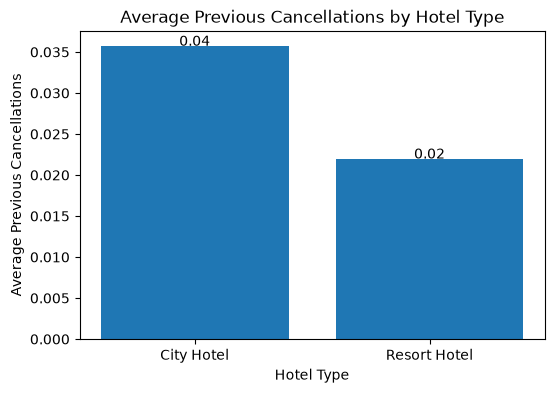

In [100]:
plt.figure(figsize=(6,4))
bars = plt.bar(avg_prev_cancel.index, avg_prev_cancel.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

plt.title('Average Previous Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Previous Cancellations')
plt.show()

**Business Insight**

- City Hotels may attract more business travelers or short-notice bookings, which can lead to slightly higher cancellation tendencies.
- Resort Hotel guests are generally more committed to their travel plans, resulting in fewer prior cancellations.
- Since previous cancellation rates are low across both hotel types, factors such as lead time, pricing, seasonality, and booking channel may have a greater impact on cancellations than guest history alone.

**Conclusion**

The analysis shows that City Hotel guests have a slightly higher average previous cancellation rate (0.04) than Resort Hotel guests (0.02). While there is a difference between the two hotel types, the overall values are very low, indicating that previous cancellations are not a major driver of booking behavior and should be analyzed alongside other factors when developing cancellation management strategies.

## 6. What is the trend of ADR over the years?

### Average ADR by Year

In [101]:
adr_trend = (
    df_cleaned.groupby('arrival_date_year')['adr']
    .mean()
    .sort_index()
)

print(adr_trend.round(2))

arrival_date_year
2015     92.45
2016    101.57
2017    118.92
Name: adr, dtype: float64


### Visualization

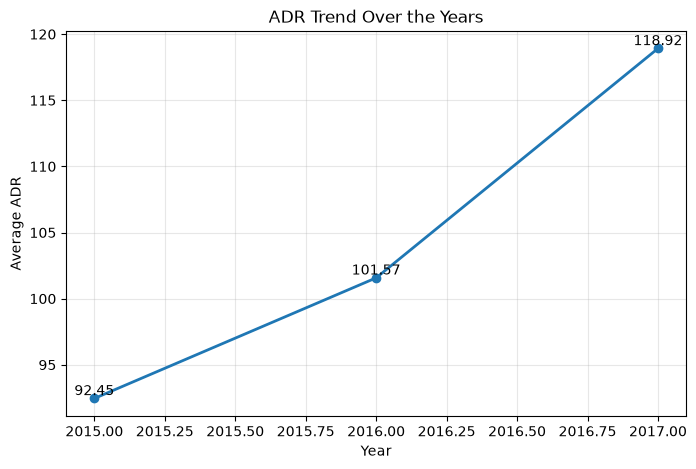

In [102]:
plt.figure(figsize=(8,5))

plt.plot(
    adr_trend.index,
    adr_trend.values,
    marker='o',
    linewidth=2
)

for x, y in zip(adr_trend.index, adr_trend.values):
    plt.text(x, y, f'{y:.2f}', ha='center', va='bottom')

plt.title('ADR Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Average ADR')
plt.grid(alpha=0.3)

plt.show()

**Business Insight**

- The steady increase in ADR indicates that the hotel was able to charge higher room rates over time.
- This growth may be driven by increased demand, improved occupancy, enhanced services, or effective revenue management strategies.
- The largest increase occurred between 2016 and 2017, suggesting stronger market performance or successful pricing optimization during that period.
- Rising ADR reflects the hotel's ability to generate more revenue per occupied room without necessarily increasing the number of bookings.

**Conclusion**

The analysis reveals a strong positive ADR trend, increasing from 92.45 in 2015 to 118.92 in 2017. This represents an overall growth of 28.63%, indicating successful pricing and revenue management strategies. The upward trend suggests that the hotel improved its ability to generate higher revenue per room over the years while maintaining market demand.

## 7. Which month has the highest revenue?

### Calculate total revenue (sum of ADR) by month

In [103]:
month_revenue = (
    df_cleaned.groupby('arrival_date_month')['adr']
    .sum()
)

# Arrange months in calendar order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

month_revenue = month_revenue.reindex(month_order)

print(month_revenue.round(2))

# Highest revenue month
top_month = month_revenue.idxmax()
top_revenue = month_revenue.max()

print(f"\nHighest Revenue Month: {top_month}")
print(f"Total Revenue: {top_revenue:.2f}")

arrival_date_month
January       328635.99
February      455344.94
March         607639.95
April         819231.89
May           928588.36
June          929668.88
July         1362782.84
August       1698163.63
September     749690.39
October       625022.56
November      362799.38
December      417840.94
Name: adr, dtype: float64

Highest Revenue Month: August
Total Revenue: 1698163.63


### Visualization

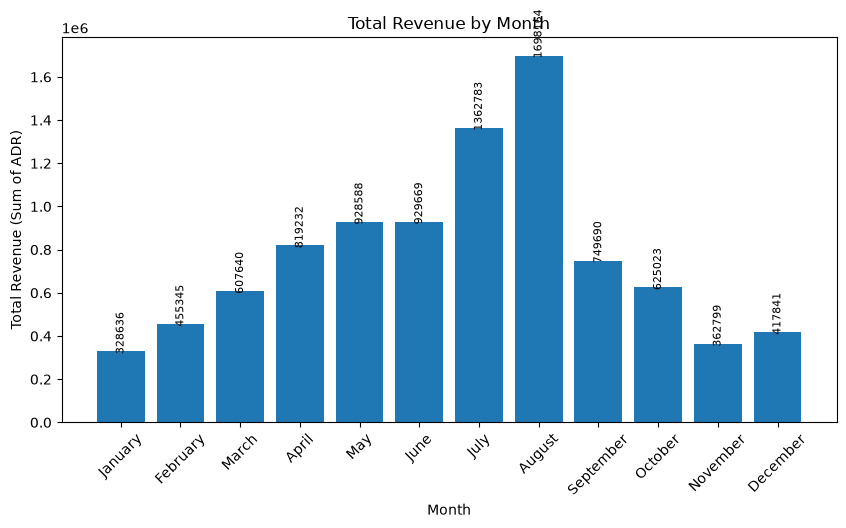

In [104]:
plt.figure(figsize=(10,5))

bars = plt.bar(month_revenue.index, month_revenue.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        fontsize=8,
        rotation=90
    )

plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Sum of ADR)')
plt.xticks(rotation=45)

plt.show()

**Business Insight**

- August is the peak revenue month, indicating the highest guest demand and occupancy during this period.
- July and August together contribute a significant share of annual revenue, suggesting a strong summer/holiday travel season.
- Revenue drops noticeably from September onward, indicating the start of the off-season.
- The hotel can maximize profits by applying dynamic pricing strategies during high-demand months such as July and August.
- Lower-performing months (November, January, December) may require promotional campaigns and discounts to boost occupancy.

**Conclusion**

The hotel's revenue shows a clear seasonal pattern, with August emerging as the most profitable month (≈ 1.70 million revenue). Demand rises steadily through the first half of the year, peaks in July–August, and declines afterward. Management should focus on maximizing room rates and occupancy during peak months while implementing targeted marketing and promotional offers during low-demand periods to maintain revenue throughout the year.

## 8. What is the impact of special requests on ADR?

### Average ADR by number of special request

In [105]:
special_request_adr = (
    df_cleaned.groupby('total_of_special_requests')['adr']
    .mean()
    .sort_index()
)

print(special_request_adr.round(2))

# Correlation
correlation = df_cleaned['total_of_special_requests'].corr(df_cleaned['adr'])

print(f"\nCorrelation between Special Requests and ADR: {correlation:.3f}")

total_of_special_requests
0     99.80
1    109.78
2    118.70
3    125.23
4    131.09
5    129.98
Name: adr, dtype: float64

Correlation between Special Requests and ADR: 0.146


### Visualization

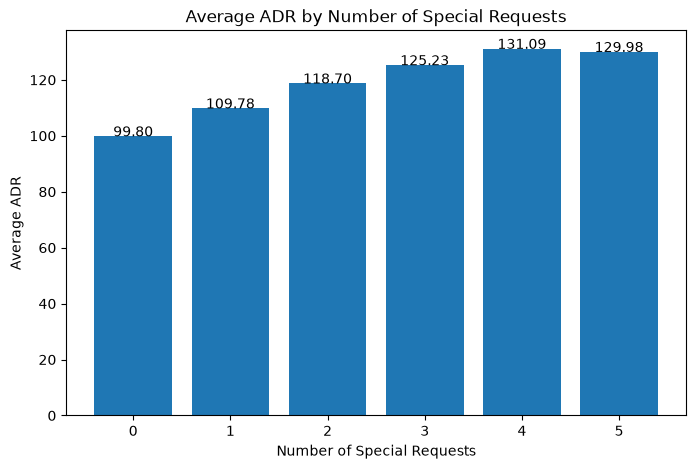

In [106]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    special_request_adr.index.astype(str),
    special_request_adr.values
)

plt.title('Average ADR by Number of Special Requests')
plt.xlabel('Number of Special Requests')
plt.ylabel('Average ADR')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

plt.show()

**Business Insight**

- There is a positive relationship between the number of special requests and ADR.
- Guests with no special requests pay an average ADR of 99.80, while guests with 4 special requests pay an average ADR of 131.09.
- ADR increases steadily as the number of special requests increases, suggesting that guests requesting additional services are often willing to pay more.
- The correlation (0.146) is positive but relatively weak, indicating that special requests influence ADR, but other factors such as hotel type, season, room type, and market segment also play significant roles.
- Guests with multiple special requests likely represent higher-value customers who seek personalized experiences and premium services.

**Conclusion**

The analysis shows a positive association between special requests and room rates. Average ADR rises from 99.80 for guests with no special requests to over 131 for guests with four special requests. Although the correlation (0.146) is not strong, it indicates that customers who make more special requests generally generate higher revenue. Hotels can use this insight to identify high-value guests and offer personalized upgrades, premium packages, and targeted services to maximize revenue and customer satisfaction.

## 9. What is the average stay duration for repeated guests versus new guests?

In [107]:
# Create total stay duration
df_cleaned['total_stay'] = (
    df_cleaned['stays_in_week_nights'] +
    df_cleaned['stays_in_weekend_nights']
)

# Average stay duration by guest type
stay_duration = (
    df_cleaned.groupby('is_repeated_guest')['total_stay']
    .mean()
)

print(stay_duration.round(2))

is_repeated_guest
0    3.70
1    1.95
Name: total_stay, dtype: float64


### Visualization

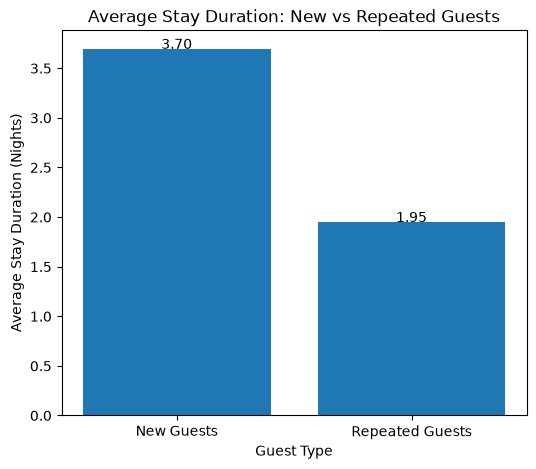

In [108]:
guest_labels = ['New Guests', 'Repeated Guests']

plt.figure(figsize=(6,5))
bars = plt.bar(
    guest_labels,
    stay_duration.values
)

plt.title('Average Stay Duration: New vs Repeated Guests')
plt.xlabel('Guest Type')
plt.ylabel('Average Stay Duration (Nights)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

plt.show()

**Business Insight**

- New guests stay almost twice as long as repeated guests (3.70 vs 1.95 nights).
- Repeated guests appear to make shorter, more frequent visits, possibly due to business travel, loyalty memberships, or familiarity with the hotel.
- New guests contribute more room nights per booking, making them important for maximizing occupancy and revenue.
- Repeated guests, although staying for shorter durations, represent a loyal customer base and may generate recurring revenue over time.
- The hotel can design different strategies for each segment:
- New Guests: Promote extended-stay packages, vacation bundles, and upselling opportunities.
- Repeated Guests: Offer loyalty rewards, express check-in benefits, and personalized offers to encourage longer stays.

**Conclusion**

The analysis reveals a significant difference in stay patterns between guest types. New guests stay an average of 3.70 nights, while repeated guests stay only 1.95 nights. This suggests that new guests contribute more room nights per reservation, whereas repeated guests tend to make shorter visits. Hotel management should focus on retaining new guests and encouraging repeat customers to extend their stays through targeted loyalty and promotional programs.

## 10. Which room type has the highest number of bookings?

In [109]:
room_bookings = (
    df_cleaned['reserved_room_type']
    .value_counts()
)

print(room_bookings)

# Highest booked room type
top_room = room_bookings.idxmax()
top_bookings = room_bookings.max()

percentage = (top_bookings / len(df_cleaned)) * 100

print(f"\nMost Booked Room Type: {top_room}")
print(f"Bookings: {top_bookings}")
print(f"Percentage of Total Bookings: {percentage:.2f}%")

reserved_room_type
A    56417
D    17373
E     6035
F     2820
G     2050
B      996
C      914
H      596
L        6
Name: count, dtype: int64

Most Booked Room Type: A
Bookings: 56417
Percentage of Total Bookings: 64.69%


### Visualization

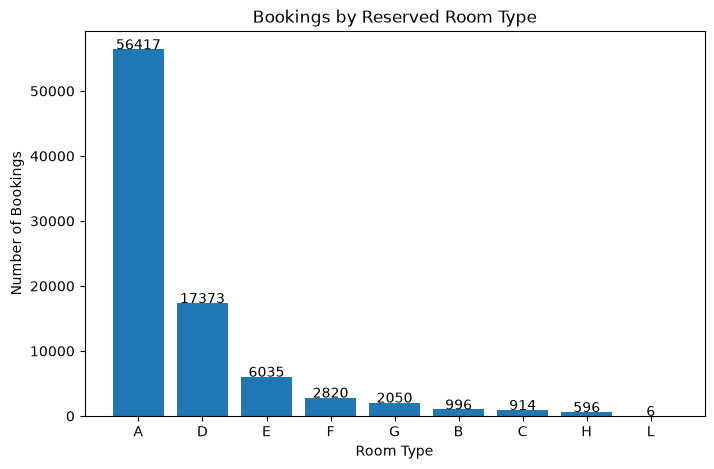

In [110]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    room_bookings.index,
    room_bookings.values
)

plt.title('Bookings by Reserved Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Bookings')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center'
    )

plt.show()

**Business Insight**

- Room Type A dominates demand, accounting for nearly 65% of all bookings.
- Demand is highly concentrated in one room category, indicating that most guests prefer this room type due to its pricing, features, or availability.
- Room Type D is the second most popular but trails far behind Type A.
- Premium or niche room types (F, G, H, L) contribute only a small portion of total bookings.

**Conclusion**

Room Type A is the hotel's primary revenue driver and should receive priority in inventory planning and occupancy management.
The hotel should ensure maximum availability of Room Type A during peak seasons to avoid lost bookings.
Since demand for Room Type D is also significant, it can serve as an upgrade option when Room Type A reaches full occupancy.
Low-demand room types may require promotional packages, pricing adjustments, or repositioning to improve utilization.

# ADVANCED LEVEL QUESTIONS

## 1. What factors significantly impact the cancellation rate?

### Select Features

In [111]:
features = [
    'lead_time',
    'previous_cancellations',
    'booking_changes',
    'total_of_special_requests',
    'adr'
]

X = df_cleaned[features]
y = df_cleaned['is_canceled']

### Train Logistic Regression

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Feature Importance

In [113]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                     Feature  Coefficient
1     previous_cancellations     0.605266
4                        adr     0.007367
0                  lead_time     0.005185
3  total_of_special_requests    -0.460922
2            booking_changes    -0.497491


### Visualization

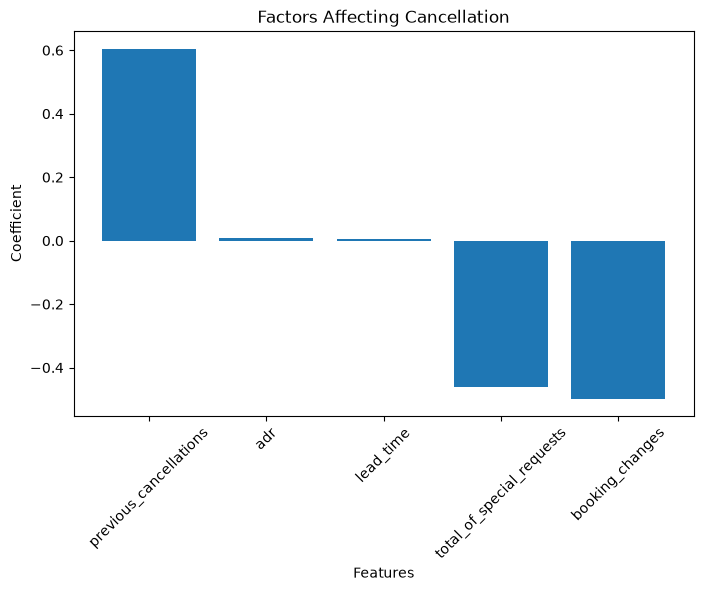

In [114]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Coefficient']
)

plt.title('Factors Affecting Cancellation')
plt.xlabel('Features')
plt.ylabel('Coefficient')

plt.xticks(rotation=45)

plt.show()

### Modal Accuracy

In [115]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 73.79%


**Model Performance**

Logistic Regression Accuracy: 73.79%
The model correctly predicts cancellation outcomes nearly 74% of the time, indicating a reasonably good predictive model.

**Business Insight**

The analysis shows that customer behavior variables have a much stronger influence on cancellations than pricing variables.

The biggest cancellation risks come from:

- Guests with previous cancellation history.
- Guests booking far in advance.
- Higher-priced reservations.

The strongest indicators of booking commitment are:

- Making special requests.
- Modifying reservations instead of canceling them.

**Conclusion**

The hotel should focus on reducing cancellations by targeting high-risk guests with previous cancellation records and long lead-time bookings. At the same time, encouraging special requests and flexible booking modifications can improve guest commitment and reduce cancellation rates. With a model accuracy of 73.79%, these factors provide reliable insights for designing cancellation prevention strategies and improving revenue stability.

## 2. How does the ADR vary with the number of adults, children, and babies?

### Define Features and Target

In [116]:
features = ['adults', 'children', 'babies']

X = df_cleaned[features]
y = df_cleaned['adr']

### Train the modal

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[32.86,38.39, 7.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['adults','children','babies']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.35
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


### Feature Imapct Analysis

In [119]:
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

    Feature  Coefficient
1  children    38.389023
0    adults    32.858807
2    babies     7.606461


### Visualization

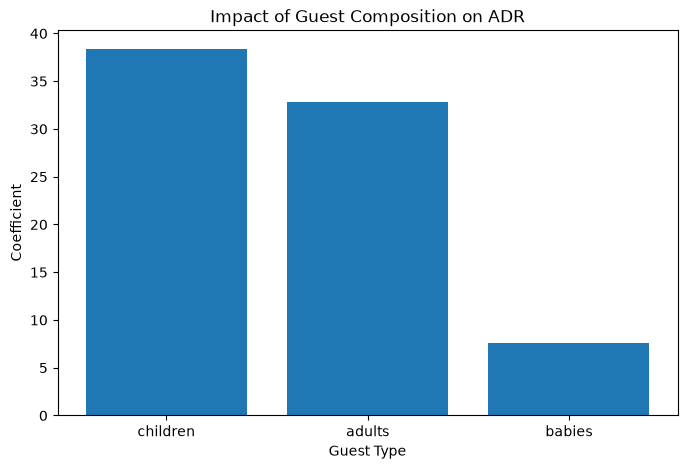

In [120]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Coefficient']
)

plt.title('Impact of Guest Composition on ADR')
plt.xlabel('Guest Type')
plt.ylabel('Coefficient')

plt.show()

### Modal Performance

In [121]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.3f}")

R² Score: 0.214


### Average ADR by Guest Type (Additional Insight)

In [122]:
guest_adr = df_cleaned.groupby(
    ['adults','children','babies']
)['adr'].mean().reset_index()

guest_adr.head()

,adults,children,babies,adr
0,0,1,0,84.532500
1,0,2,0,82.873930
2,0,2,1,91.413333
3,0,3,0,41.120000
4,1,0,0,79.006291


**Model Performance**

R² Score: 0.214
The model explains approximately 21.4% of the variation in ADR.
This indicates that guest composition has a noticeable impact on ADR, but other factors (hotel type, season, room type, market segment, etc.) also influence room pricing.

**Business Insight**

- Family bookings are more valuable than solo traveler bookings.
- Children drive the largest increase in room revenue.
- Larger guest groups often require upgraded room categories and additional hotel services.
- Hotels can maximize revenue by targeting family travelers and group bookings.

**Conclusion**

The analysis shows that guest composition directly affects ADR, with children having the strongest impact, followed by adults, while babies contribute the least. Family-oriented reservations generate higher room revenue because they often require larger accommodations and additional services.

Hotels should focus on:

- Promoting family packages.
- Offering premium family rooms and suites.
- Creating child-friendly amenities to attract higher-value bookings.

Overall, family and group travelers represent an important revenue segment and should be a key focus of pricing and marketing strategies.

## 3. What is the impact of booking changes on guest satisfaction as indicated by special requests?

### Calculate Correlation

In [123]:
correlation = df_cleaned['booking_changes'].corr(
    df_cleaned['total_of_special_requests']
)

print(f"Correlation: {correlation:.3f}")

Correlation: 0.018


### Average Special Requests by Booking Changes

In [124]:
booking_special = (
    df_cleaned.groupby('booking_changes')['total_of_special_requests']
    .mean()
    .sort_index()
)

print(booking_special.round(2))

booking_changes
0     0.70
1     0.68
2     0.74
3     0.84
4     0.84
5     0.84
6     0.89
7     0.66
8     1.00
9     0.12
10    1.67
11    0.00
12    0.00
13    0.80
14    1.00
15    1.33
16    2.00
17    1.00
18    3.00
Name: total_of_special_requests, dtype: float64


### Visualization

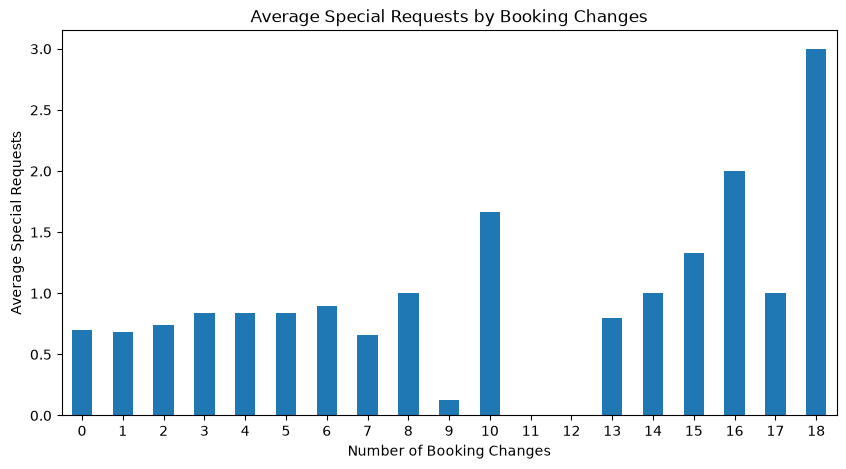

In [125]:
plt.figure(figsize=(10,5))

booking_special.plot(
    kind='bar'
)

plt.title('Average Special Requests by Booking Changes')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Average Special Requests')

plt.xticks(rotation=0)

plt.show()

### Scatter Plot

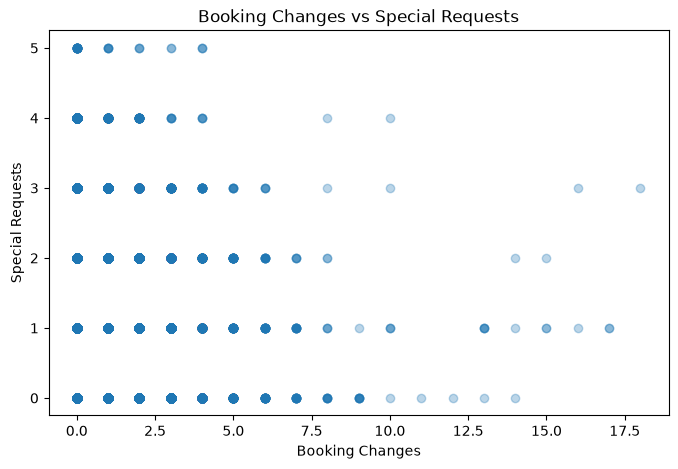

In [126]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_cleaned['booking_changes'],
    df_cleaned['total_of_special_requests'],
    alpha=0.3
)

plt.title('Booking Changes vs Special Requests')
plt.xlabel('Booking Changes')
plt.ylabel('Special Requests')

plt.show()

### Regression Line

In [127]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df_cleaned[['booking_changes']]
y = df_cleaned['total_of_special_requests']

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² Score:", model.score(X, y))

Coefficient: 0.021438097456562118
Intercept: 0.6933162125523709
R² Score: 0.00033526112702753075


**Business Insight**

- The correlation between booking changes and total special requests is 0.018, which is extremely close to 0.
- This indicates almost no relationship between the number of booking modifications and the number of special requests made by guests.

The linear regression model also supports this finding:
- Coefficient: 0.021
- R² Score: 0.0003
- An R² value near zero means booking changes explain virtually none of the variation in special requests.

Although a few guests with many booking changes (10–18 changes) show higher average special requests, these cases are rare and do not represent the overall trend.

Most guests, regardless of whether they make 0, 1, or several booking changes, submit a similar number of special requests (around 0.7–0.9 on average).

**Conclusion**

There is no significant impact of booking changes on guest satisfaction as measured by special requests. Guests who modify their bookings are not substantially more or less likely to request additional services or accommodations.

## 4. What is the seasonal impact on booking cancellations?

### Cancellation rate by month

In [128]:
monthly_cancel = (
    df_cleaned.groupby('arrival_date_month')['is_canceled']
    .mean()
    * 100
)

# Arrange months in calendar order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_cancel = monthly_cancel.reindex(month_order)

print(monthly_cancel.round(2))

arrival_date_month
January      22.14
February     23.22
March        24.42
April        30.46
May          29.27
June         30.34
July         31.83
August       32.22
September    24.47
October      23.68
November     21.16
December     26.94
Name: is_canceled, dtype: float64


### Visualization

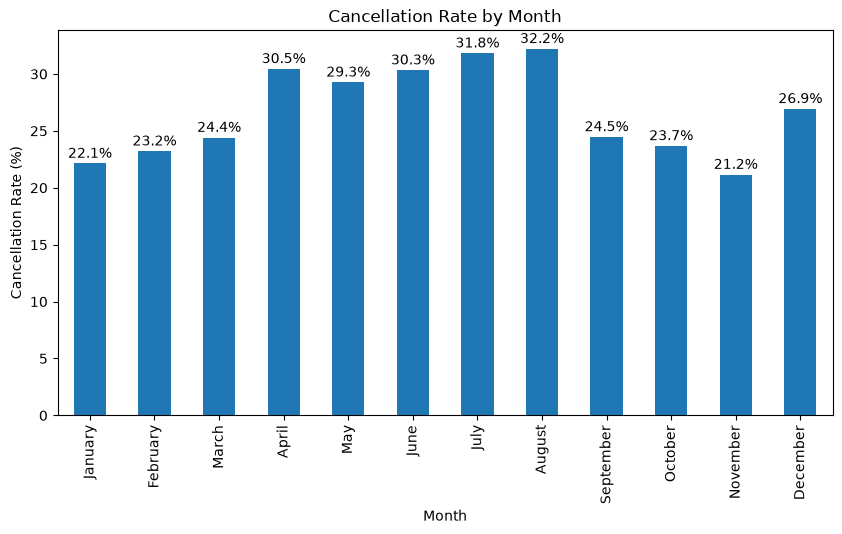

In [129]:
plt.figure(figsize=(10,5))
monthly_cancel.plot(kind='bar')

plt.title('Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')

for i, v in enumerate(monthly_cancel):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.show()

### Find Highest & Lowest Cancellation Month

In [130]:
highest_month = monthly_cancel.idxmax()
highest_rate = monthly_cancel.max()

lowest_month = monthly_cancel.idxmin()
lowest_rate = monthly_cancel.min()

print(f"Highest Cancellation Month: {highest_month} ({highest_rate:.2f}%)")
print(f"Lowest Cancellation Month: {lowest_month} ({lowest_rate:.2f}%)")

Highest Cancellation Month: August (32.22%)
Lowest Cancellation Month: November (21.16%)


**Business Insight**

Booking cancellations show a clear seasonal pattern throughout the year.

The highest cancellation rate occurs in August (32.22%), followed by:
- July (31.83%)
- April (30.46%)
- June (30.34%)
- May (29.27%)

The lowest cancellation rate occurs in November (21.16%), followed by:
- January (22.14%)
- February (23.22%)
- October (23.68%)
Cancellation rates increase significantly during the summer and peak vacation season (April–August), where rates consistently exceed 29%.

After August, cancellations decline sharply and remain relatively low during September–November.

**Conclusion**

There is a strong seasonal impact on booking cancellations. Peak travel months, especially July and August, experience the highest cancellation rates, while November has the most stable bookings with the lowest cancellation rate.

## 5. How does the booking lead time distribution vary between different market segments?

### Average lead time by market segment

In [131]:
lead_time_segment = (
    df_cleaned.groupby('market_segment')['lead_time']
    .agg(['mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

print(lead_time_segment.round(2))

                  mean  median  min  max
market_segment                          
Groups          147.91   115.0    0  629
Offline TA/TO   106.08    82.0    0  532
Online TA        79.97    55.0    0  403
Direct           48.69    15.0    0  737
Corporate        16.27     5.0    0  343
Complementary    13.82     3.0    0  386
Aviation          4.30     3.0    0   23
Undefined         1.50     1.5    1    2


### Box Plot

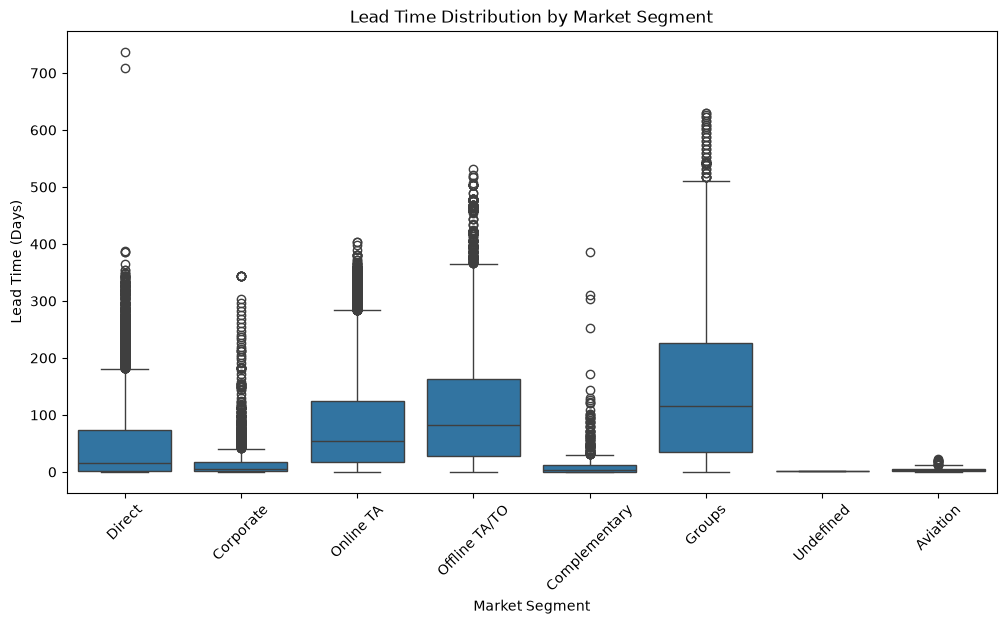

In [132]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_cleaned,
    x='market_segment',
    y='lead_time'
)

plt.title('Lead Time Distribution by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Lead Time (Days)')
plt.xticks(rotation=45)

plt.show()

### Identify Highest Average Lead Time Segment

In [133]:
avg_lead = df_cleaned.groupby('market_segment')['lead_time'].mean()

top_segment = avg_lead.idxmax()
top_lead = avg_lead.max()

print(f"Market Segment with Highest Lead Time: {top_segment}")
print(f"Average Lead Time: {top_lead:.2f} days")

Market Segment with Highest Lead Time: Groups
Average Lead Time: 147.91 days


**Highest Lead Time Segment**

Market Segment with Highest Average Lead Time: Groups

Average Lead Time: 147.91 days

**Business Insight**

- Hotels should target Groups and Offline TA/TO customers with early-bird offers since they plan far ahead.
- Corporate and Direct segments can be targeted with last-minute promotions.
- Understanding lead-time behavior helps improve revenue management, forecasting, and inventory planning.

**Conclusion**

The lead time distribution varies significantly across market segments. Group bookings are planned the earliest (147.91 days on average), while Corporate, Aviation, and Complementary bookings are typically made close to the arrival date, indicating different customer planning behaviors and marketing opportunities.